# Statistical Analysis — Sales vs Other Factors
Goal: identify correlations between `Sales` and other factors (Customers, Promo, Day of Week, School/State Holiday, Store Type).

Data: `cleaned_train` + `cleaned_store`, merged on `Store`. Statistics use **open days only** (`Open == 1`): closed days always have `Sales = 0` and would drag every average down.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from IPython.display import Markdown, display

plt.rcParams.update({'figure.dpi': 100, 'axes.grid': True, 'grid.alpha': 0.3, 'axes.spines.top': False, 'axes.spines.right': False})

# Colab: files next to the notebook. Repo: ../dataset/cleaned
DATA = Path('.') if Path('cleaned_store.csv').exists() else Path('../dataset/cleaned')
train_path = next(p for p in [DATA/'cleaned_train.csv', DATA/'cleaned_train.zip'] if p.exists())

train = pd.read_csv(train_path, dtype={'StateHoliday': str}, parse_dates=['Date'])
store = pd.read_csv(DATA/'cleaned_store.csv')
df = train.merge(store, on='Store', how='left')
o = df[df['Open'] == 1].copy()          # open days only
print(f'All rows: {len(df):,} | open days: {len(o):,} ({len(o)/len(df):.1%}) | stores: {df.Store.nunique()}')
print(f'Period: {df.Date.min().date()} -> {df.Date.max().date()}')

All rows: 1,017,155 | open days: 844,338 (83.0%) | stores: 1115
Period: 2013-01-01 -> 2015-07-31


## 1. Overall statistics

In [2]:
aggs = ['count', 'mean', 'median', 'std', 'min', 'max']
overall = o[['Sales', 'Customers']].agg(aggs).round(1)
overall['SalesPerCustomer'] = (o['Sales'] / o['Customers']).agg(aggs).round(2).values
overall

,Sales,Customers,SalesPerCustomer
count,844338.0,844338.0,844338.00
mean,6956.0,762.8,9.49
median,6369.0,676.0,9.25
std,3103.8,401.2,2.20
min,46.0,8.0,2.75
max,41551.0,7388.0,64.96


## 2. Sales vs Customers

Pearson r = 0.824 | Spearman rho = 0.832


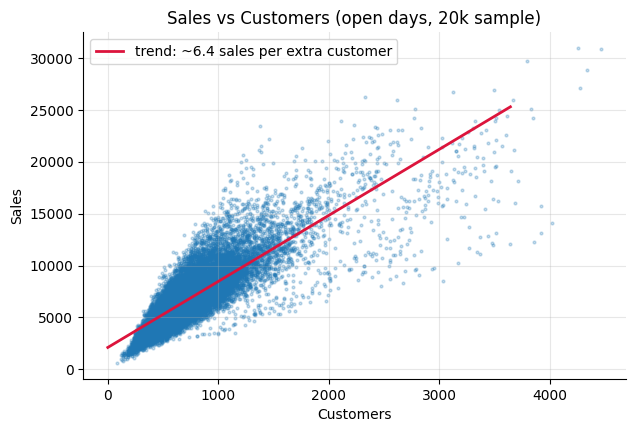

In [3]:
pearson = o['Sales'].corr(o['Customers'])
spearman = o['Sales'].corr(o['Customers'], method='spearman')
print(f'Pearson r = {pearson:.3f} | Spearman rho = {spearman:.3f}')

s = o.sample(20000, random_state=1)
slope, intercept = np.polyfit(o['Customers'], o['Sales'], 1)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(s['Customers'], s['Sales'], s=4, alpha=0.25)
xs = np.linspace(0, o['Customers'].quantile(0.999), 100)
ax.plot(xs, intercept + slope * xs, color='crimson', lw=2, label=f'trend: ~{slope:.1f} sales per extra customer')
ax.set(title='Sales vs Customers (open days, 20k sample)', xlabel='Customers', ylabel='Sales')
ax.legend(); plt.show()

## 3. Sales with / without Promo

,count,mean,median,std,mean_vs_overall_%
Promo,,,,,
0,467463,5929.8,5459.0,2629.3,-14.8
1,376875,8228.7,7650.0,3175.3,18.3


Mean difference: 2,299 (38.8%) | Welch t-test p = 0
Same-store uplift: median 40.6% | stores with higher sales on promo: 99.9%


,avg_customers,sales_per_customer
Promo,,
0,696.9,8.94
1,844.5,10.18


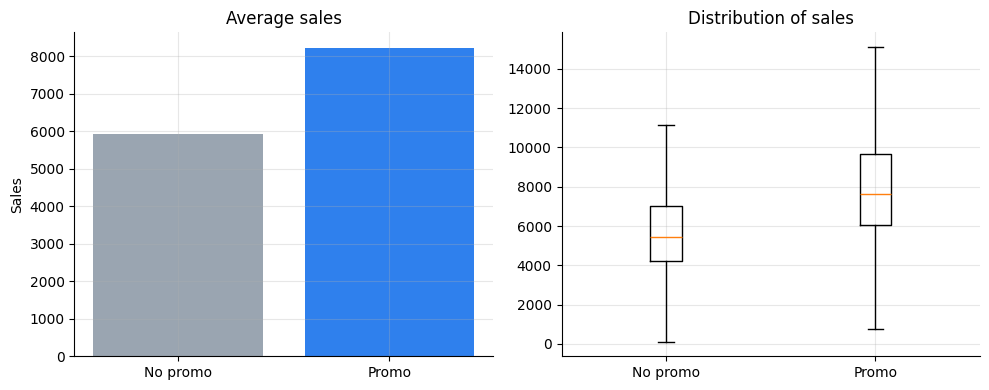

In [4]:
def group_stats(data, col):
    g = data.groupby(col, observed=True)['Sales'].agg(['count', 'mean', 'median', 'std']).round(1)
    g['mean_vs_overall_%'] = ((g['mean'] / data['Sales'].mean() - 1) * 100).round(1)
    return g

def welch(col):
    a = o.loc[o[col] == 1, 'Sales']; b = o.loc[o[col] == 0, 'Sales']
    t, p = stats.ttest_ind(a, b, equal_var=False)
    return a.mean() - b.mean(), p

promo_tbl = group_stats(o, 'Promo')
display(promo_tbl)

diff, p = welch('Promo')
promo_uplift = promo_tbl.loc[1, 'mean'] / promo_tbl.loc[0, 'mean'] - 1
print(f'Mean difference: {diff:,.0f} ({promo_uplift:.1%}) | Welch t-test p = {p:.2g}')

# same-store comparison (removes store-size effect)
pm = o.groupby(['Store', 'Promo'])['Sales'].mean().unstack().dropna()
pm['uplift_%'] = (pm[1] / pm[0] - 1) * 100
print(f'Same-store uplift: median {pm["uplift_%"].median():.1f}% | stores with higher sales on promo: {(pm["uplift_%"] > 0).mean():.1%}')

cust_promo = o.groupby('Promo')['Customers'].mean().round(1)
spc_promo = (o['Sales'] / o['Customers']).groupby(o['Promo']).mean().round(2)
display(pd.DataFrame({'avg_customers': cust_promo, 'sales_per_customer': spc_promo}))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(['No promo', 'Promo'], promo_tbl['mean'], color=['#9aa5b1', '#2f80ed'])
axes[0].set(title='Average sales', ylabel='Sales')
axes[1].boxplot([o.loc[o.Promo == 0, 'Sales'], o.loc[o.Promo == 1, 'Sales']], tick_labels=['No promo', 'Promo'], showfliers=False)
axes[1].set(title='Distribution of sales')
plt.tight_layout(); plt.show()

## 4. Sales by Day of Week

,count,mean,median,std,mean_vs_overall_%,open_rate_%
DayOfWeek,,,,,,
Mon,137557,8216.3,7539.0,3691.6,18.1,95.0
Tue,143955,7088.4,6502.0,3066.0,1.9,98.8
Wed,141922,6728.8,6210.0,2781.1,-3.3,97.4
Thu,134626,6768.2,6246.0,2763.6,-2.7,92.3
Fri,138633,7073.0,6581.0,2764.5,1.7,95.1
Sat,144052,5875.1,5425.0,2852.5,-15.5,99.5
Sun,3593,8224.7,6876.0,6235.2,18.2,2.5


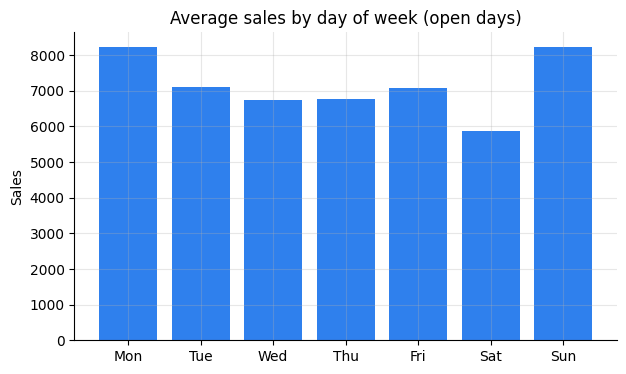

In [5]:
dow_names = {1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat', 7: 'Sun'}
dow_tbl = group_stats(o, 'DayOfWeek')
dow_tbl['open_rate_%'] = (df.groupby('DayOfWeek')['Open'].mean() * 100).round(1)
dow_tbl.index = dow_tbl.index.map(dow_names)
display(dow_tbl)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(dow_tbl.index, dow_tbl['mean'], color='#2f80ed')
ax.set(title='Average sales by day of week (open days)', ylabel='Sales')
plt.show()

Sunday has very few open stores (about 2.5% of store-days), so its average is based on a small, unusual group of stores and should be read with care.

## 5. Sales with / without School Holiday

In [6]:
school_tbl = group_stats(o, 'SchoolHoliday')
display(school_tbl)
diff, p = welch('SchoolHoliday')
school_uplift = school_tbl.loc[1, 'mean'] / school_tbl.loc[0, 'mean'] - 1
print(f'Mean difference: {diff:,.0f} ({school_uplift:.1%}) | Welch t-test p = {p:.2g}')

,count,mean,median,std,mean_vs_overall_%
SchoolHoliday,,,,,
0,680893,6897.2,6326.0,3083.4,-0.8
1,163445,7200.7,6562.0,3175.8,3.5


Mean difference: 304 (4.4%) | Welch t-test p = 4.9e-266


## 6. Sales with / without State Holiday

,count,mean,median,std,mean_vs_overall_%,open_rate_%
StateHoliday,,,,,,
None,843428,6954.0,6368.0,3098.5,-0.0,85.5
Public holiday,694,8487.5,7556.0,5708.6,22.0,3.4
Easter,145,9887.9,8423.0,7551.8,42.2,2.2
Christmas,71,9743.7,8397.0,5980.9,40.1,1.7


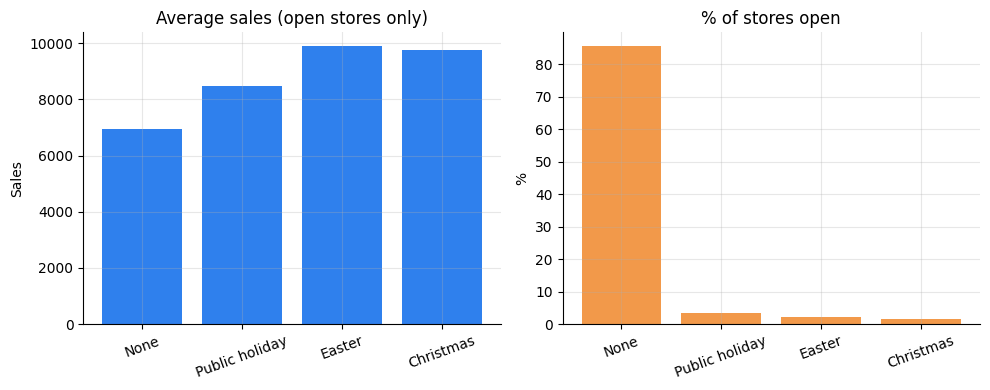

In [7]:
sh_names = {'0': 'None', 'a': 'Public holiday', 'b': 'Easter', 'c': 'Christmas'}
sh_tbl = group_stats(o, 'StateHoliday')
sh_tbl['open_rate_%'] = (df.groupby('StateHoliday')['Open'].mean() * 100).round(1)
sh_tbl.index = sh_tbl.index.map(sh_names)
display(sh_tbl)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(sh_tbl.index, sh_tbl['mean'], color='#2f80ed'); axes[0].set(title='Average sales (open stores only)', ylabel='Sales')
axes[1].bar(sh_tbl.index, sh_tbl['open_rate_%'], color='#f2994a'); axes[1].set(title='% of stores open', ylabel='%')
for a in axes: a.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

## 7. Sales by Store Type

,count,mean,median,std,mean_vs_overall_%,stores
StoreType,,,,,,
a,457042,6925.7,6285.0,3277.4,-0.4,602
b,15560,10233.4,9130.0,5155.7,47.1,17
c,112968,6933.1,6408.0,2897.0,-0.3,148
d,258768,6822.3,6395.0,2556.4,-1.9,348


,count,mean,median,std,mean_vs_overall_%
Assortment,,,,,
a,444875,6621.5,6082.0,2972.1,-4.8
b,8209,8642.5,8088.0,3803.1,24.2
c,391254,7300.8,6675.0,3183.8,5.0


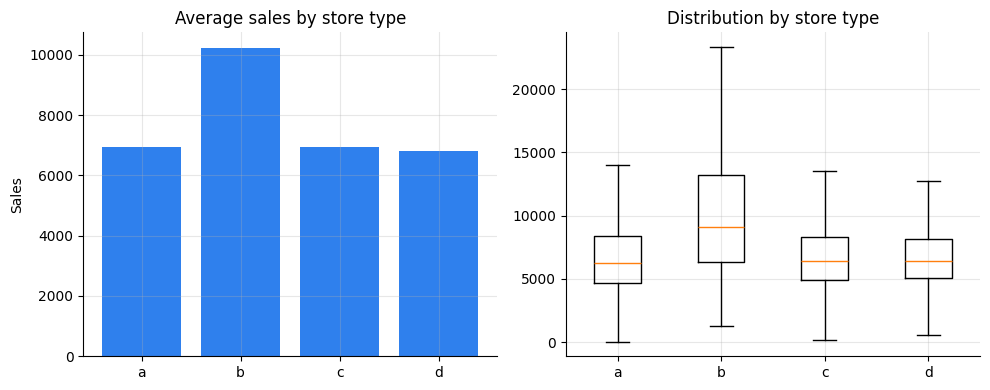

In [8]:
type_tbl = group_stats(o, 'StoreType')
type_tbl['stores'] = store.groupby('StoreType')['Store'].count()
display(type_tbl)
display(group_stats(o, 'Assortment'))

order = sorted(o['StoreType'].unique())
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(order, type_tbl.loc[order, 'mean'], color='#2f80ed'); axes[0].set(title='Average sales by store type', ylabel='Sales')
axes[1].boxplot([o.loc[o.StoreType == t, 'Sales'] for t in order], tick_labels=order, showfliers=False); axes[1].set(title='Distribution by store type')
plt.tight_layout(); plt.show()

## 8. Correlations

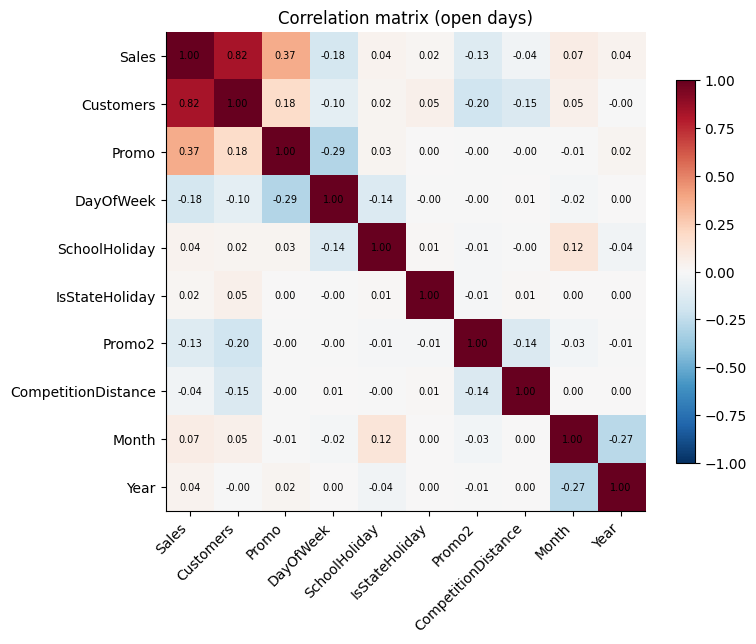

Customers              0.824
Promo                  0.368
DayOfWeek             -0.179
Promo2                -0.128
Month                  0.074
SchoolHoliday          0.039
Year                   0.036
CompetitionDistance   -0.036
IsStateHoliday         0.020
Name: Sales, dtype: float64

In [9]:
o2 = o.assign(IsStateHoliday=(o['StateHoliday'] != '0').astype(int), Month=o['Date'].dt.month, Year=o['Date'].dt.year)
cols = ['Sales', 'Customers', 'Promo', 'DayOfWeek', 'SchoolHoliday', 'IsStateHoliday', 'Promo2', 'CompetitionDistance', 'Month', 'Year']
corr = o2[cols].corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(cols)), cols, rotation=45, ha='right'); ax.set_yticks(range(len(cols)), cols)
for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=7)
ax.grid(False); fig.colorbar(im, shrink=0.8); ax.set_title('Correlation matrix (open days)')
plt.tight_layout(); plt.show()

sales_corr = corr['Sales'].drop('Sales').sort_values(key=abs, ascending=False).round(3)
sales_corr

## 9. Business insights

In [10]:
best_day = dow_tbl.loc[[d for d in dow_tbl.index if d != 'Sun'], 'mean'].idxmax()
worst_day = dow_tbl.loc[[d for d in dow_tbl.index if d != 'Sun'], 'mean'].idxmin()
t_other = o.loc[o.StoreType != 'b', 'Sales'].mean()

display(Markdown(f'''
1. **Customers drive sales.** Sales and customers are strongly correlated (Pearson r = {pearson:.2f}); each extra customer adds roughly {slope:.1f} in sales.
2. **Promotions work.** Average sales are {promo_uplift:.0%} higher on promo days ({promo_tbl.loc[1, 'mean']:,.0f} vs {promo_tbl.loc[0, 'mean']:,.0f}). The same stores sell more on promo days (median uplift {pm['uplift_%'].median():.0f}%, {(pm['uplift_%'] > 0).mean():.1%} of stores). The lift comes from both more customers ({cust_promo[1]:.0f} vs {cust_promo[0]:.0f}) and higher spend per customer ({spc_promo[1]:.2f} vs {spc_promo[0]:.2f}).
3. **Day of week matters.** {best_day} is the strongest regular day ({dow_tbl.loc[best_day, 'mean']:,.0f}) and {worst_day} the weakest ({dow_tbl.loc[worst_day, 'mean']:,.0f}). Only about 2.5% of store-days are open on Sunday.
4. **School holidays have a small positive effect** ({school_uplift:+.1%} on average sales), much weaker than promotions.
5. **State holidays: most stores close** (only {sh_tbl.loc['Public holiday', 'open_rate_%']:.0f}% open on public holidays, about {sh_tbl.loc['Christmas', 'open_rate_%']:.0f}% on Christmas). The few stores that stay open sell more than usual ({sh_tbl.loc['Public holiday', 'mean']:,.0f} on public holidays vs {sh_tbl.loc['None', 'mean']:,.0f} on normal days).
6. **Store type b is the top performer** ({type_tbl.loc['b', 'mean']:,.0f} average sales, {type_tbl.loc['b', 'mean'] / t_other - 1:.0%} above the other types) but it is a small group ({int(type_tbl.loc['b', 'stores'])} stores). Types a, c and d are close to each other.
7. **Correlation ranking with Sales:** {', '.join(f'{k} ({v:+.2f})' for k, v in sales_corr.head(4).items())}.
'''))


1. **Customers drive sales.** Sales and customers are strongly correlated (Pearson r = 0.82); each extra customer adds roughly 6.4 in sales.
2. **Promotions work.** Average sales are 39% higher on promo days (8,229 vs 5,930). The same stores sell more on promo days (median uplift 41%, 99.9% of stores). The lift comes from both more customers (844 vs 697) and higher spend per customer (10.18 vs 8.94).
3. **Day of week matters.** Mon is the strongest regular day (8,216) and Sat the weakest (5,875). Only about 2.5% of store-days are open on Sunday.
4. **School holidays have a small positive effect** (+4.4% on average sales), much weaker than promotions.
5. **State holidays: most stores close** (only 3% open on public holidays, about 2% on Christmas). The few stores that stay open sell more than usual (8,488 on public holidays vs 6,954 on normal days).
6. **Store type b is the top performer** (10,233 average sales, 48% above the other types) but it is a small group (17 stores). Types a, c and d are close to each other.
7. **Correlation ranking with Sales:** Customers (+0.82), Promo (+0.37), DayOfWeek (-0.18), Promo2 (-0.13).


## Notes
- Correlation is not causation: promo days, store type and customer traffic overlap, so effects should be read together.
- `DayOfWeek` is a category, not a quantity, so its linear correlation (-0.18) is of limited meaning; use the day-by-day table instead.
- `Promo2` has a slightly negative association with sales. It reflects which stores joined the program (store mix), not a negative effect of the promotion itself.